In [1]:
pip install psycopg2-binary sqlalchemy python-dotenv lifetimes pandas numpy lightgbm lifelines 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\abduh\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [2]:

import os
from dotenv import load_dotenv

load_dotenv()

required_vars = ["DB_HOST", "DB_PORT", "DB_NAME", "DB_USER", "DB_PASSWORD"]

missing_vars = [var for var in required_vars if os.getenv(var) is None]

if missing_vars:
    raise ValueError(f"Missing environment variables: {missing_vars}")
else:
    print("All environment variables loaded successfully")

DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")

All environment variables loaded successfully


In [3]:
from sqlalchemy import create_engine, text

try:
    engine = create_engine(
        f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
    )

    with engine.connect() as conn:
        result = conn.execute(text("SELECT 1"))
        print("Connection successfull:", result.scalar())

except Exception as e:
    print("Connection failed")
    print(e)

Connection successfull: 1


In [4]:
import pandas as pd

query = """
SELECT 
    invoice_no,
    stock_code,
    quantity,
    unit_price,
    invoice_date,
    customer_id,
    country,
    country_invalid,
    rn,
    revenue
FROM public.int_retail_filtered;
"""
df_light = pd.read_sql(query, engine)
df_light.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1021419 entries, 0 to 1021418
Data columns (total 10 columns):
 #   Column           Non-Null Count    Dtype         
---  ------           --------------    -----         
 0   invoice_no       1021419 non-null  object        
 1   stock_code       1021419 non-null  object        
 2   quantity         1021419 non-null  int64         
 3   unit_price       1021419 non-null  float64       
 4   invoice_date     1021419 non-null  datetime64[ns]
 5   customer_id      787193 non-null   object        
 6   country          1021419 non-null  object        
 7   country_invalid  1021419 non-null  int64         
 8   rn               1021419 non-null  int64         
 9   revenue          1021419 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(4)
memory usage: 77.9+ MB


In [5]:
import pandas as pd
import numpy as np
from datetime import timedelta
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, roc_auc_score, average_precision_score
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')

# Try to import lifetimes for probabilistic models
try:
    from lifetimes import BetaGeoFitter, GammaGammaFitter, ParetoNBDFitter
    LIFETIMES_AVAILABLE = True
except ImportError:
    LIFETIMES_AVAILABLE = False
    print("Note: 'lifetimes' package not installed. Install with: pip install lifetimes")

df_clean = df_light.copy()
df_clean = df_clean[~df_clean['invoice_no'].astype(str).str.startswith('C')]
df_clean = df_clean[df_clean['quantity'] > 0]
df_clean = df_clean[df_clean['unit_price'] > 0]
print(f"Rows after cleaning: {len(df_clean)}")


Rows after cleaning: 996504


In [6]:
orders = df_clean.groupby(['customer_id', 'invoice_no']).agg({
    'invoice_date': 'first',
    'revenue': 'sum',
    'quantity': 'sum',
    'stock_code': 'nunique'
}).rename(columns={'stock_code': 'unique_products'}).reset_index()

orders = orders.sort_values(['customer_id', 'invoice_date'])
orders['order_date'] = orders['invoice_date'].dt.date
print(f"Created {len(orders)} orders from {len(df_clean)} transactions")


Created 36968 orders from 996504 transactions


In [7]:
orders.head()

,customer_id,invoice_no,invoice_date,revenue,quantity,unique_products,order_date
0,12346.0,491725,2009-12-14 08:34:00,45.0,10,1,2009-12-14
1,12346.0,491742,2009-12-14 11:00:00,22.5,5,1,2009-12-14
2,12346.0,491744,2009-12-14 11:02:00,22.5,5,1,2009-12-14
3,12346.0,492718,2009-12-18 10:47:00,22.5,5,1,2009-12-18
4,12346.0,492722,2009-12-18 10:55:00,1.0,1,1,2009-12-18


In [8]:
# OPTIMIZED: VECTORIZED CUSTOMER FEATURES
print("\n" + "="*60)
print("SINGLE SNAPSHOT PER CUSTOMER (OPTIMIZED)")
print("="*60)

# Start timing
import time
start_time = time.time()

snapshot_date = pd.Timestamp('2011-04-01')
holdout_days = 180
holdout_end = snapshot_date + timedelta(days=holdout_days)

print(f"Snapshot date: {snapshot_date.date()}")
print(f"Holdout window: {holdout_days} days until {holdout_end.date()}")

# Split orders into historical and future
historical_orders = orders[orders['invoice_date'] < snapshot_date].copy()
future_orders = orders[(orders['invoice_date'] >= snapshot_date) & 
                        (orders['invoice_date'] <= holdout_end)].copy()

print(f"Historical orders: {len(historical_orders)}")
print(f"Future orders: {len(future_orders)}")

# Get customers active before snapshot
active_customers = historical_orders['customer_id'].unique()
print(f"Customers with activity before snapshot: {len(active_customers)}")

# ============================================================================
# 1. AGGREGATE HISTORICAL FEATURES (Vectorized)
# ============================================================================
print("\nComputing historical features...")

# Sort for gap calculations
historical_orders = historical_orders.sort_values(['customer_id', 'invoice_date'])

# Calculate order gaps per customer
historical_orders['prev_date'] = historical_orders.groupby('customer_id')['invoice_date'].shift(1)
historical_orders['order_gap'] = (historical_orders['invoice_date'] - historical_orders['prev_date']).dt.days
historical_orders['order_num'] = historical_orders.groupby('customer_id').cumcount() + 1

# Aggregate historical features
historical_features = historical_orders.groupby('customer_id').agg({
    'invoice_date': ['min', 'max', 'count'],  # first, last, frequency
    'revenue': ['sum', 'mean', 'std'],  # monetary
    'order_gap': ['mean', 'std', 'max'],  # timing patterns
    'unique_products': ['sum', 'mean'],  # product diversity
    'order_num': ['count']  # total orders (same as invoice_date count)
}).round(2)

# Flatten column names
historical_features.columns = ['first_purchase_date', 'last_purchase_date', 'frequency',
                                'total_revenue', 'avg_order_value', 'std_order_value',
                                'avg_gap_days', 'std_gap_days', 'max_gap_days',
                                'unique_products_total', 'avg_unique_products',
                                'order_count']
historical_features = historical_features.reset_index()

# Calculate tenure and recency
historical_features['tenure_days'] = (snapshot_date - historical_features['first_purchase_date']).dt.days
historical_features['recency_days'] = (snapshot_date - historical_features['last_purchase_date']).dt.days
historical_features['repeat_frequency'] = historical_features['frequency'] - 1

# Fill NaN for std (when only 1 order)
historical_features['std_order_value'] = historical_features['std_order_value'].fillna(0)
historical_features['std_gap_days'] = historical_features['std_gap_days'].fillna(0)
historical_features['max_gap_days'] = historical_features['max_gap_days'].fillna(0)

# ============================================================================
# 2. RECENT ACTIVITY (Last 30 days before snapshot)
# ============================================================================
print("\nComputing recent activity...")
recent_cutoff = snapshot_date - timedelta(days=30)

recent_activity = historical_orders[historical_orders['invoice_date'] >= recent_cutoff].groupby('customer_id').agg({
    'invoice_date': 'count',
    'revenue': 'sum'
}).rename(columns={'invoice_date': 'orders_last_30d', 'revenue': 'revenue_last_30d'})

historical_features = historical_features.merge(recent_activity, on='customer_id', how='left')
historical_features['orders_last_30d'] = historical_features['orders_last_30d'].fillna(0).astype(int)
historical_features['revenue_last_30d'] = historical_features['revenue_last_30d'].fillna(0)

# ============================================================================
# 3. CUSTOMER TYPE FLAGS
# ============================================================================
historical_features['is_new'] = (historical_features['tenure_days'] <= 30)
historical_features['is_dormant'] = (historical_features['recency_days'] > 90) & (historical_features['frequency'] > 0)
historical_features['purchase_regularity'] = historical_features['avg_gap_days'] / (historical_features['std_gap_days'] + 1e-5)
historical_features['revenue_volatility'] = historical_features['std_order_value'] / (historical_features['avg_order_value'] + 1e-5)

# ============================================================================
# 4. COUNTRY (Most common per customer)
# ============================================================================
print("\nComputing country mode...")
# Get most frequent country per customer
country_mode = df_clean.groupby('customer_id')['country'].agg(lambda x: x.mode()[0] if len(x) > 0 else 'Unknown')
historical_features = historical_features.merge(country_mode, on='customer_id', how='left')
historical_features.rename(columns={'country': 'country'}, inplace=True)

# ============================================================================
# 5. FUTURE TARGETS (Vectorized)
# ============================================================================
print("\nComputing future targets...")
future_targets = future_orders.groupby('customer_id').agg({
    'invoice_date': 'count',
    'revenue': 'sum'
}).rename(columns={'invoice_date': 'future_purchase_count', 'revenue': 'future_revenue'})

historical_features = historical_features.merge(future_targets, on='customer_id', how='left')
historical_features['future_purchase_count'] = historical_features['future_purchase_count'].fillna(0).astype(int)
historical_features['future_revenue'] = historical_features['future_revenue'].fillna(0)
historical_features['future_avg_order_value'] = np.where(
    historical_features['future_purchase_count'] > 0,
    historical_features['future_revenue'] / historical_features['future_purchase_count'],
    0
)
historical_features['had_activity'] = (historical_features['future_purchase_count'] > 0).astype(int)

# ============================================================================
# 6. ADD SNAPSHOT DATE
# ============================================================================
historical_features['snapshot_date'] = snapshot_date

# ============================================================================
# FINAL STATE TABLE
# ============================================================================
state_table = historical_features.copy()

# Reorder columns to match original structure
column_order = ['customer_id', 'snapshot_date', 
                'first_purchase_date', 'last_purchase_date', 
                'frequency', 'repeat_frequency', 'total_revenue', 
                'avg_order_value', 'std_order_value',
                'tenure_days', 'recency_days', 
                'avg_gap_days', 'std_gap_days', 'max_gap_days',
                'unique_products_total', 'avg_unique_products',
                'orders_last_30d', 'revenue_last_30d',
                'is_new', 'is_dormant', 'purchase_regularity', 'revenue_volatility',
                'country', 'future_purchase_count', 'future_revenue', 
                'future_avg_order_value', 'had_activity']

state_table = state_table[[col for col in column_order if col in state_table.columns]]

# Calculate elapsed time
elapsed_time = time.time() - start_time

print(f"\n Created {len(state_table)} customer snapshots in {elapsed_time:.2f} seconds")
print(f"Features per customer: {len(state_table.columns)}")


SINGLE SNAPSHOT PER CUSTOMER (OPTIMIZED)
Snapshot date: 2011-04-01
Holdout window: 180 days until 2011-09-28
Historical orders: 23141
Future orders: 8210
Customers with activity before snapshot: 4716

Computing historical features...

Computing recent activity...

Computing country mode...

Computing future targets...

 Created 4716 customer snapshots in 1.67 seconds
Features per customer: 27


In [9]:

# CUSTOMER-LEVEL SPLIT (No customer appears in multiple sets)
print("\n" + "="*60)
print("CUSTOMER-LEVEL TRAIN/VALIDATION/TEST SPLIT")
print("="*60)

np.random.seed(42)
customers = state_table['customer_id'].unique()
np.random.shuffle(customers)

train_customers = customers[:int(len(customers) * 0.6)]
val_customers = customers[int(len(customers) * 0.6):int(len(customers) * 0.8)]
test_customers = customers[int(len(customers) * 0.8):]

train_data = state_table[state_table['customer_id'].isin(train_customers)].copy()
val_data = state_table[state_table['customer_id'].isin(val_customers)].copy()
test_data = state_table[state_table['customer_id'].isin(test_customers)].copy()

print(f"Train: {len(train_data)} customers")
print(f"Validation: {len(val_data)} customers")
print(f"Test: {len(test_data)} customers")
print("No customer appears in multiple sets (true out-of-sample)")



CUSTOMER-LEVEL TRAIN/VALIDATION/TEST SPLIT
Train: 2829 customers
Validation: 943 customers
Test: 944 customers
No customer appears in multiple sets (true out-of-sample)


In [10]:
# Quick diagnostic
print("Columns in state_table:")
print(state_table.columns.tolist())
print("\nData types:")
print(state_table.dtypes)
print(f"\nTotal columns: {len(state_table.columns)}")
print(f"Numeric columns: {len(state_table.select_dtypes(include=[np.number]).columns)}")

Columns in state_table:
['customer_id', 'snapshot_date', 'first_purchase_date', 'last_purchase_date', 'frequency', 'repeat_frequency', 'total_revenue', 'avg_order_value', 'std_order_value', 'tenure_days', 'recency_days', 'avg_gap_days', 'std_gap_days', 'max_gap_days', 'unique_products_total', 'avg_unique_products', 'orders_last_30d', 'revenue_last_30d', 'is_new', 'is_dormant', 'purchase_regularity', 'revenue_volatility', 'country', 'future_purchase_count', 'future_revenue', 'future_avg_order_value', 'had_activity']

Data types:
customer_id                       object
snapshot_date              datetime64[s]
first_purchase_date       datetime64[ns]
last_purchase_date        datetime64[ns]
frequency                          int64
repeat_frequency                   int64
total_revenue                    float64
avg_order_value                  float64
std_order_value                  float64
tenure_days                        int64
recency_days                       int64
avg_gap_days   

In [11]:
# FEATURE PREPARATION
print("\n" + "="*60)
print("FEATURE PREPARATION")
print("="*60)

# These columns EXIST in your state_table and are appropriate as features
# Note: I've removed 'total_revenue' to prevent leakage (it's too predictive)
feature_cols = [
    'frequency',           # Number of past orders
    'repeat_frequency',    # Frequency - 1 (for Pareto/NBD)
    'tenure_days',         # Customer age
    'recency_days',        # Days since last purchase
    'avg_order_value',     # Average spend per order
    'std_order_value',     # Consistency of spend
    # 'total_revenue',     # REMOVED - causes data leakage!
    'avg_gap_days',        # Average time between purchases
    'std_gap_days',        # Consistency of purchase timing
    'max_gap_days',        # Longest gap (churn indicator)
    'unique_products_total', # Product variety (sum)
    'avg_unique_products',   # Product variety per order
    'orders_last_30d',     # Recent frequency
    'revenue_last_30d',    # Recent monetary value
    'is_new',              # Boolean: new customer
    'is_dormant',          # Boolean: at risk of churn
    'purchase_regularity', # Regularity score (avg/std)
    'revenue_volatility'   # Spend consistency
]

# Verify all feature columns exist
missing_cols = [col for col in feature_cols if col not in state_table.columns]
if missing_cols:
    print(f"WARNING: Missing columns: {missing_cols}")
else:
    print(f"✓ All {len(feature_cols)} feature columns confirmed")
    print(f"Features: {feature_cols}")

# Prepare the data splits (assuming train_data, val_data, test_data already exist)
# If not, create them from state_table first
if 'train_data' not in locals():
    print("\nCreating train/val/test splits from state_table...")
    np.random.seed(42)
    customers = state_table['customer_id'].unique()
    np.random.shuffle(customers)
    
    train_customers = customers[:int(len(customers) * 0.6)]
    val_customers = customers[int(len(customers) * 0.6):int(len(customers) * 0.8)]
    test_customers = customers[int(len(customers) * 0.8):]
    
    train_data = state_table[state_table['customer_id'].isin(train_customers)].copy()
    val_data = state_table[state_table['customer_id'].isin(val_customers)].copy()
    test_data = state_table[state_table['customer_id'].isin(test_customers)].copy()
    
    print(f"Train: {len(train_data)} customers")
    print(f"Validation: {len(val_data)} customers")
    print(f"Test: {len(test_data)} customers")

# Encode country as category
for df in [train_data, val_data, test_data]:
    if 'country' in df.columns:
        df['country_cat'] = df['country'].astype('category')
        print(f"✓ Encoded country for {len(df)} customers")
    else:
        print(f"WARNING: 'country' column not found")

# Quick check of feature availability in training data
available_features = [col for col in feature_cols if col in train_data.columns]
print(f"\ Using {len(available_features)} features for modeling")
print(f"Sample feature values (first customer):")
print(train_data[available_features].iloc[0])


FEATURE PREPARATION
✓ All 17 feature columns confirmed
Features: ['frequency', 'repeat_frequency', 'tenure_days', 'recency_days', 'avg_order_value', 'std_order_value', 'avg_gap_days', 'std_gap_days', 'max_gap_days', 'unique_products_total', 'avg_unique_products', 'orders_last_30d', 'revenue_last_30d', 'is_new', 'is_dormant', 'purchase_regularity', 'revenue_volatility']
✓ Encoded country for 2829 customers
✓ Encoded country for 943 customers
✓ Encoded country for 944 customers
\ Using 17 features for modeling
Sample feature values (first customer):
frequency                      12
repeat_frequency               11
tenure_days                   472
recency_days                   72
avg_order_value           6463.04
std_order_value          22271.23
avg_gap_days                35.91
std_gap_days                65.43
max_gap_days                203.0
unique_products_total          34
avg_unique_products          2.83
orders_last_30d                 0
revenue_last_30d              0.0
is_

In [12]:
# HURDLE LIGHTGBM MODEL
print("\n" + "="*60)
print("HURDLE LIGHTGBM MODEL")
print("="*60)

# Safety check: Ensure feature_cols exists and has the right columns
if 'feature_cols' not in locals():
    feature_cols = ['frequency', 'repeat_frequency', 'tenure_days', 'recency_days',
                    'avg_order_value', 'std_order_value', 'avg_gap_days', 'std_gap_days', 
                    'max_gap_days', 'unique_products_total', 'avg_unique_products',
                    'orders_last_30d', 'revenue_last_30d', 'is_new', 'is_dormant', 
                    'purchase_regularity', 'revenue_volatility']

# Verify all feature columns exist in train_data
missing_features = [col for col in feature_cols if col not in train_data.columns]
if missing_features:
    print(f"ERROR: Missing features: {missing_features}")
    print("Available columns:", train_data.columns.tolist())
    raise KeyError(f"Missing columns: {missing_features}")

print(f"Using {len(feature_cols)} features: {feature_cols[:5]}... (showing first 5)")

# Component 1: Activation (P(active))
print("\n" + "-"*40)
print("Component 1: Activation Model (Binary Classification)")
print("-"*40)

activation_model = lgb.LGBMClassifier(
    n_estimators=100, 
    max_depth=5, 
    learning_rate=0.05,
    subsample=0.8, 
    random_state=42, 
    verbosity=-1,
    categorical_feature=['country_cat']
)

activation_model.fit(
    train_data[feature_cols + ['country_cat']],
    train_data['had_activity'],
    eval_set=[(val_data[feature_cols + ['country_cat']], val_data['had_activity'])],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(10), lgb.log_evaluation(0)]
)

# Predict probabilities
for df in [train_data, val_data, test_data]:
    df['p_active'] = activation_model.predict_proba(df[feature_cols + ['country_cat']])[:, 1]

print(f"  P(active) range: [{train_data['p_active'].min():.3f}, {train_data['p_active'].max():.3f}]")
print(f"  Training AUC: {activation_model.best_score_['valid_0']['auc']:.4f}")

# Component 2: Conditional Frequency (E[Purchases | Active])
print("\n" + "-"*40)
print("Component 2: Conditional Frequency Model (Poisson Regression)")
print("-"*40)

# Only train on customers who made future purchases
train_active = train_data[train_data['had_activity'] == 1].copy()
val_active = val_data[val_data['had_activity'] == 1].copy()
test_active = test_data[test_data['had_activity'] == 1].copy()

print(f"  Active customers - Train: {len(train_active)}, Val: {len(val_active)}, Test: {len(test_active)}")

if len(train_active) == 0:
    raise ValueError("No active customers in training set! Check 'had_activity' column.")

freq_model = lgb.LGBMRegressor(
    n_estimators=100, 
    max_depth=5, 
    learning_rate=0.05,
    subsample=0.8, 
    random_state=42, 
    verbosity=-1,
    objective='poisson',  # For count data (0,1,2,3...)
    categorical_feature=['country_cat']
)

freq_model.fit(
    train_active[feature_cols + ['country_cat']],
    train_active['future_purchase_count'],
    eval_set=[(val_active[feature_cols + ['country_cat']], val_active['future_purchase_count'])],
    eval_metric='mae',
    callbacks=[lgb.early_stopping(10), lgb.log_evaluation(0)]
)

for df in [train_data, val_data, test_data]:
    df['pred_frequency_conditional'] = freq_model.predict(df[feature_cols + ['country_cat']])
    df['pred_frequency_conditional'] = df['pred_frequency_conditional'].clip(lower=0)

print(f"  Expected purchases | active range: [{train_data['pred_frequency_conditional'].min():.2f}, {train_data['pred_frequency_conditional'].max():.2f}]")

# Component 3: Conditional Monetary (E[AOV | Active])
print("\n" + "-"*40)
print("Component 3: Conditional Monetary Model (Tweedie Regression)")
print("-"*40)

# Filter out customers with zero AOV (shouldn't happen in active set)
monetary_train = train_active[train_active['future_avg_order_value'] > 0].copy()
monetary_val = val_active[val_active['future_avg_order_value'] > 0].copy()

print(f"  Customers with AOV>0 - Train: {len(monetary_train)}, Val: {len(monetary_val)}")

monetary_model = lgb.LGBMRegressor(
    n_estimators=100, 
    max_depth=5, 
    learning_rate=0.05,
    subsample=0.8, 
    random_state=42, 
    verbosity=-1,
    objective='tweedie',  # For zero-inflated positive values
    tweedie_variance_power=1.5,  # Between 1 (Poisson) and 2 (Gamma)
    categorical_feature=['country_cat']
)

monetary_model.fit(
    monetary_train[feature_cols + ['country_cat']],
    monetary_train['future_avg_order_value'],
    eval_set=[(monetary_val[feature_cols + ['country_cat']], monetary_val['future_avg_order_value'])],
    eval_metric='mae',
    callbacks=[lgb.early_stopping(10), lgb.log_evaluation(0)]
)

for df in [train_data, val_data, test_data]:
    df['pred_monetary_conditional'] = monetary_model.predict(df[feature_cols + ['country_cat']])
    df['pred_monetary_conditional'] = df['pred_monetary_conditional'].clip(lower=0)

print(f"  Expected AOV | active range: ${train_data['pred_monetary_conditional'].min():.2f} - ${train_data['pred_monetary_conditional'].max():.2f}")

# Combined CLV (Corrected formula)
print("\n" + "-"*40)
print("Component 4: Combined CLV Calculation")
print("-"*40)

for df in [train_data, val_data, test_data]:
    # Expected purchases = P(active) * E[Purchases | Active]
    df['pred_future_purchases'] = df['p_active'] * df['pred_frequency_conditional']
    
    # Expected revenue = P(active) * E[Purchases | Active] * E[AOV | Active]
    df['pred_future_revenue'] = df['p_active'] * df['pred_frequency_conditional'] * df['pred_monetary_conditional']

# Summary statistics
print(f"\nCLV Predictions Summary (Test Set):")
print(f"  - Mean predicted revenue: ${test_data['pred_future_revenue'].mean():.2f}")
print(f"  - Median predicted revenue: ${test_data['pred_future_revenue'].median():.2f}")
print(f"  - Max predicted revenue: ${test_data['pred_future_revenue'].max():.2f}")
print(f"  - % customers predicted active: {(test_data['p_active'] > 0.5).mean()*100:.1f}%")

# Check for any obvious issues
if test_data['pred_future_revenue'].isna().any():
    print(" WARNING: NaN values detected in predictions!")
    
if (test_data['pred_future_revenue'] < 0).any():
    print(" WARNING: Negative predictions detected!")


HURDLE LIGHTGBM MODEL
Using 17 features: ['frequency', 'repeat_frequency', 'tenure_days', 'recency_days', 'avg_order_value']... (showing first 5)

----------------------------------------
Component 1: Activation Model (Binary Classification)
----------------------------------------
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[48]	valid_0's auc: 0.800581	valid_0's binary_logloss: 0.537323
  P(active) range: [0.061, 0.951]
  Training AUC: 0.8006

----------------------------------------
Component 2: Conditional Frequency Model (Poisson Regression)
----------------------------------------
  Active customers - Train: 1317, Val: 438, Test: 437


  File "C:\Users\abduh\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\abduh\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\abduh\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\abduh\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
            

Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's l1: 1.31432	valid_0's poisson: -1.03912
  Expected purchases | active range: [1.46, 66.79]

----------------------------------------
Component 3: Conditional Monetary Model (Tweedie Regression)
----------------------------------------
  Customers with AOV>0 - Train: 1317, Val: 438
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[67]	valid_0's l1: 134.117	valid_0's tweedie: 72.4116
  Expected AOV | active range: $108.78 - $7955.10

----------------------------------------
Component 4: Combined CLV Calculation
----------------------------------------

CLV Predictions Summary (Test Set):
  - Mean predicted revenue: $605.56
  - Median predicted revenue: $260.07
  - Max predicted revenue: $24407.90
  - % customers predicted active: 41.0%


In [13]:
#  PARETO/NBD + GAMMA-GAMMA 
print("="*60)
print("PROBABILISTIC BASELINES")
print("="*60)

if LIFETIMES_AVAILABLE:
    from lifetimes.utils import summary_data_from_transaction_data
    from lifetimes.fitters import ConvergenceError
    
    # Prepare data for lifetimes
    transaction_data = df_clean[['customer_id', 'invoice_date', 'revenue']].copy()
    transaction_data['invoice_date'] = pd.to_datetime(transaction_data['invoice_date'])
    
    # Define function to fit probabilistic models with better convergence
    def fit_probabilistic_model(train_customers_list, snapshot_date):
        """Fit BG/NBD and Pareto/NBD on training customers only"""
        
        # Filter transactions to training customers
        train_transactions = transaction_data[transaction_data['customer_id'].isin(train_customers_list)]
        
        print(f"  Training transactions: {len(train_transactions)}")
        print(f"  Unique training customers: {train_transactions['customer_id'].nunique()}")
        
        # Create summary
        summary = summary_data_from_transaction_data(
            train_transactions,
            'customer_id',
            'invoice_date',
            'revenue',
            observation_period_end=snapshot_date
        )
        
        print(f"  Summary created with {len(summary)} customers")
        print(f"  Frequency range: {summary['frequency'].min()} - {summary['frequency'].max()}")
        print(f"  Customers with zero frequency: {(summary['frequency'] == 0).sum()}")
        
        # Fit BG/NBD - try with increasing penalizer if convergence fails
        print("\n  Fitting BG/NBD...")
        penalizers = [0.01, 0.1, 0.5, 1.0, 10.0]
        bg = None
        
        for penalizer in penalizers:
            try:
                bg = BetaGeoFitter(penalizer_coef=penalizer)
                bg.fit(summary['frequency'], summary['recency'], summary['T'])
                print(f"    BG/NBD converged with penalizer={penalizer}")
                break
            except ConvergenceError:
                print(f"    BG/NBD did not converge with penalizer={penalizer}, trying larger...")
                continue
        
        if bg is None:
            print("    WARNING: BG/NBD failed to converge with all penalizers")
            bg = BetaGeoFitter(penalizer_coef=10.0)
            bg.fit(summary['frequency'], summary['recency'], summary['T'], disp=False)
        
        # Fit Pareto/NBD
        print("  Fitting Pareto/NBD...")
        pnbd = None
        
        for penalizer in penalizers:
            try:
                pnbd = ParetoNBDFitter(penalizer_coef=penalizer)
                pnbd.fit(summary['frequency'], summary['recency'], summary['T'])
                print(f"    Pareto/NBD converged with penalizer={penalizer}")
                break
            except ConvergenceError:
                print(f"    Pareto/NBD did not converge with penalizer={penalizer}, trying larger...")
                continue
        
        if pnbd is None:
            print("    WARNING: Pareto/NBD failed to converge with all penalizers")
            pnbd = ParetoNBDFitter(penalizer_coef=10.0)
            pnbd.fit(summary['frequency'], summary['recency'], summary['T'], disp=False)
        
        # Fit Gamma-Gamma for monetary value
        print("  Fitting Gamma-Gamma...")
        gg = GammaGammaFitter(penalizer_coef=0.1)
        # Filter customers with at least 1 repeat purchase for monetary model
        monetary_summary = summary[summary['frequency'] > 0].copy()
        
        if len(monetary_summary) > 0:
            try:
                gg.fit(monetary_summary['frequency'], monetary_summary['monetary_value'])
                print(f"    Gamma-Gamma fitted on {len(monetary_summary)} customers")
            except Exception as e:
                print(f"    Gamma-Gamma failed: {e}")
                # Use simple average if model fails
                gg = None
        else:
            print("    Warning: No customers with frequency > 0, using simple average")
            gg = None
        
        return bg, pnbd, gg
    
    # Fit on training customers (NOT test!)
    print("\nFitting models on training customers...")
    bg_model, pnbd_model, gg_model = fit_probabilistic_model(train_customers, snapshot_date)
    
    # Predict for test set
    print("\n" + "-"*40)
    print("Generating predictions for test customers...")
    print("-"*40)
    
    # Prepare test summary
    test_transactions = transaction_data[transaction_data['customer_id'].isin(test_customers)]
    test_summary = summary_data_from_transaction_data(
        test_transactions,
        'customer_id',
        'invoice_date',
        'revenue',
        observation_period_end=snapshot_date
    )
    
    print(f"  Test customers in summary: {len(test_summary)}")
    print(f"  Test customers in original test set: {len(test_data)}")
    
    # Predict future purchases (next 180 days)
    holdout_period_days = holdout_days
    
    if bg_model is not None:
        test_summary['pred_purchases_bg'] = bg_model.conditional_expected_number_of_purchases_up_to_time(
            holdout_period_days, 
            test_summary['frequency'], 
            test_summary['recency'], 
            test_summary['T']
        )
        # Fix negative predictions (shouldn't happen but clamp to 0)
        test_summary['pred_purchases_bg'] = test_summary['pred_purchases_bg'].clip(lower=0)
    else:
        # Fallback: use RFM-like prediction
        test_summary['pred_purchases_bg'] = test_summary['frequency'] * (holdout_period_days / test_summary['T'].clip(lower=1))
    
    if pnbd_model is not None:
        test_summary['pred_purchases_pnbd'] = pnbd_model.conditional_expected_number_of_purchases_up_to_time(
            holdout_period_days, 
            test_summary['frequency'], 
            test_summary['recency'], 
            test_summary['T']
        )
        # Fix negative predictions
        test_summary['pred_purchases_pnbd'] = test_summary['pred_purchases_pnbd'].clip(lower=0)
    else:
        test_summary['pred_purchases_pnbd'] = test_summary['pred_purchases_bg']  # Use BG as fallback
    
    # Predict monetary value
    if gg_model is not None:
        customers_with_purchases = test_summary[test_summary['frequency'] > 0]
        if len(customers_with_purchases) > 0:
            overall_mean_monetary = customers_with_purchases['monetary_value'].mean()
            test_summary['pred_monetary'] = gg_model.conditional_expected_average_profit(
                test_summary['frequency'], 
                test_summary['monetary_value']
            )
            # Fill NaN for customers with frequency=0
            test_summary['pred_monetary'] = test_summary['pred_monetary'].fillna(overall_mean_monetary)
            # Fix negative predictions
            test_summary['pred_monetary'] = test_summary['pred_monetary'].clip(lower=0)
        else:
            test_summary['pred_monetary'] = test_summary['monetary_value'].fillna(0).clip(lower=0)
    else:
        # Simple average as fallback
        test_summary['pred_monetary'] = test_summary['monetary_value'].fillna(0).clip(lower=0)
    
    # Combined CLV (ensure no negatives)
    test_summary['pred_revenue_bg'] = test_summary['pred_purchases_bg'] * test_summary['pred_monetary']
    test_summary['pred_revenue_pnbd'] = test_summary['pred_purchases_pnbd'] * test_summary['pred_monetary']
    
    # Final clip to ensure no negatives (due to floating point errors)
    test_summary['pred_revenue_bg'] = test_summary['pred_revenue_bg'].clip(lower=0)
    test_summary['pred_revenue_pnbd'] = test_summary['pred_revenue_pnbd'].clip(lower=0)
    
    # Merge with actuals from test_data
    test_actual = test_data[['customer_id', 'future_purchase_count', 'future_revenue']].copy()
    test_summary = test_summary.merge(test_actual, on='customer_id', how='inner')
    
    print(f"\nFinal test summary has {len(test_summary)} customers")
    print(f"Predicted revenue range (BG): ${test_summary['pred_revenue_bg'].min():.2f} - ${test_summary['pred_revenue_bg'].max():.2f}")
    print(f"Predicted revenue range (PNBD): ${test_summary['pred_revenue_pnbd'].min():.2f} - ${test_summary['pred_revenue_pnbd'].max():.2f}")
    
    # Check if negatives were fixed
    if (test_summary['pred_revenue_bg'] < 0).any():
        print(f"WARNING: Still have negative BG predictions: {(test_summary['pred_revenue_bg'] < 0).sum()}")
    if (test_summary['pred_revenue_pnbd'] < 0).any():
        print(f"WARNING: Still have negative PNBD predictions: {(test_summary['pred_revenue_pnbd'] < 0).sum()}")
    
 
    print(f"\nActual future revenue in test set:")
    print(f"  - Mean: ${test_summary['future_revenue'].mean():.2f}")
    print(f"  - Median: ${test_summary['future_revenue'].median():.2f}")
    print(f"  - % with activity: {(test_summary['future_revenue'] > 0).mean()*100:.1f}%")
    
    # Add diagnostics for the negative predictions
    print(f"\nDiagnostics - Predicted purchases range:")
    print(f"  BG purchases: {test_summary['pred_purchases_bg'].min():.3f} - {test_summary['pred_purchases_bg'].max():.3f}")
    print(f"  PNBD purchases: {test_summary['pred_purchases_pnbd'].min():.3f} - {test_summary['pred_purchases_pnbd'].max():.3f}")
    print(f"  Monetary: ${test_summary['pred_monetary'].min():.2f} - ${test_summary['pred_monetary'].max():.2f}")
    
    # Check for any remaining issues
    print(f"\nNumber of customers with zero predictions:")
    print(f"  BG revenue = 0: {(test_summary['pred_revenue_bg'] == 0).sum()} customers")
    print(f"  PNBD revenue = 0: {(test_summary['pred_revenue_pnbd'] == 0).sum()} customers")
    
else:
    print("'lifetimes' package not available - install with: pip install lifetimes")
    print("  Using RFM heuristic baseline instead...")
    
    # RFM Heuristic Baseline
    test_data['rfm_score'] = (test_data['frequency'] * test_data['avg_order_value']).fillna(0)
    test_summary = test_data[['customer_id', 'future_purchase_count', 'future_revenue', 'rfm_score']].copy()
    
    print(f"RFM baseline created with {len(test_summary)} customers")

PROBABILISTIC BASELINES

Fitting models on training customers...
  Training transactions: 433615
  Unique training customers: 2829
  Summary created with 2829 customers
  Frequency range: 0.0 - 154.0
  Customers with zero frequency: 981

  Fitting BG/NBD...
    BG/NBD converged with penalizer=0.01
  Fitting Pareto/NBD...
    Pareto/NBD converged with penalizer=0.01
  Fitting Gamma-Gamma...
    Gamma-Gamma fitted on 1848 customers

----------------------------------------
Generating predictions for test customers...
----------------------------------------
  Test customers in summary: 944
  Test customers in original test set: 944

Final test summary has 944 customers
Predicted revenue range (BG): $0.00 - $35583.50
Predicted revenue range (PNBD): $0.00 - $34509.93

Actual future revenue in test set:
  - Mean: $635.95
  - Median: $0.00
  - % with activity: 46.3%

Diagnostics - Predicted purchases range:
  BG purchases: 0.211 - 18.258
  PNBD purchases: 0.174 - 17.680
  Monetary: $0.00 - $

In [14]:
# COMPREHENSIVE EVALUATION 
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)

def evaluate_predictions(actual, predicted, model_name):
    """Calculate comprehensive metrics"""
    # Remove NaN
    mask = ~(np.isnan(actual) | np.isnan(predicted))
    actual = actual[mask]
    predicted = predicted[mask]
    
    if len(actual) == 0:
        return None
    
    # Error metrics
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted)
    
    # Ranking metrics
    spearman_corr, spearman_p = spearmanr(actual, predicted)
    
    # Decile analysis
    df_temp = pd.DataFrame({'actual': actual, 'predicted': predicted})
    df_temp = df_temp.sort_values('predicted', ascending=False)
    total_actual = actual.sum()
    
    top10_capture = df_temp.head(int(len(df_temp) * 0.1))['actual'].sum() / total_actual * 100 if total_actual > 0 else 0
    top10_lift = top10_capture / 10
    
    # Top 20% capture (often used in marketing)
    top20_capture = df_temp.head(int(len(df_temp) * 0.2))['actual'].sum() / total_actual * 100 if total_actual > 0 else 0
    
    return {
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'Spearman': spearman_corr,
        'Spearman_p': spearman_p,
        'Top10_Capture_%': top10_capture,
        'Top10_Lift': top10_lift,
        'Top20_Capture_%': top20_capture
    }

# Collect results
results = []

# LightGBM Hurdle Model
print("\n" + "-"*40)
print("Evaluating LightGBM Hurdle Model...")
print("-"*40)

# Check if predictions exist
if 'pred_future_revenue' in test_data.columns:
    lgb_result = evaluate_predictions(
        test_data['future_revenue'], 
        test_data['pred_future_revenue'],
        "LightGBM Hurdle"
    )
    if lgb_result:
        results.append(lgb_result)
        print(f"  Revenue MAE: ${lgb_result['MAE']:.2f}")
        print(f"  Revenue RMSE: ${lgb_result['RMSE']:.2f}")
        print(f"  R²: {lgb_result['R2']:.4f}")
        print(f"  Spearman correlation: {lgb_result['Spearman']:.4f} (p={lgb_result['Spearman_p']:.4f})")
        print(f"  Top 10% Capture: {lgb_result['Top10_Capture_%']:.1f}% (Lift={lgb_result['Top10_Lift']:.2f}x)")
        print(f"  Top 20% Capture: {lgb_result['Top20_Capture_%']:.1f}%")
else:
    print("  LightGBM predictions not found - run Part 5 first")

# RFM Heuristic (Improved version)
print("\n" + "-"*40)
print("Evaluating RFM Heuristic...")
print("-"*40)

# Simple RFM (historical total revenue) - original
rfm_simple = test_data['frequency'] * test_data['avg_order_value']

# Better RFM: Recency-weighted (more recent = higher weight)
# Customers who bought recently are more likely to buy again
recency_weight = np.exp(-test_data['recency_days'] / 90)  # Exponential decay with 90-day half-life
rfm_weighted = test_data['frequency'] * test_data['avg_order_value'] * recency_weight

# Try both RFM versions
rfm_result_simple = evaluate_predictions(
    test_data['future_revenue'],
    rfm_simple,
    "RFM (Frequency × AOV)"
)

if rfm_result_simple:
    results.append(rfm_result_simple)
    print(f"  RFM Simple (F × AOV):")
    print(f"    Revenue MAE: ${rfm_result_simple['MAE']:.2f}")
    print(f"    Top 10% Capture: {rfm_result_simple['Top10_Capture_%']:.1f}%")
    print(f"    Spearman: {rfm_result_simple['Spearman']:.4f}")

rfm_result_weighted = evaluate_predictions(
    test_data['future_revenue'],
    rfm_weighted,
    "RFM (Recency-Weighted)"
)

if rfm_result_weighted:
    results.append(rfm_result_weighted)
    print(f"\n  RFM Weighted (with recency decay):")
    print(f"    Revenue MAE: ${rfm_result_weighted['MAE']:.2f}")
    print(f"    Top 10% Capture: {rfm_result_weighted['Top10_Capture_%']:.1f}%")
    print(f"    Spearman: {rfm_result_weighted['Spearman']:.4f}")

# Probabilistic models
if LIFETIMES_AVAILABLE and 'pred_revenue_bg' in test_summary.columns:
    print("\n" + "-"*40)
    print("Evaluating BG/NBD + Gamma-Gamma...")
    print("-"*40)
    
    bg_result = evaluate_predictions(
        test_summary['future_revenue'],
        test_summary['pred_revenue_bg'],
        "BG/NBD + Gamma-Gamma"
    )
    if bg_result:
        results.append(bg_result)
        print(f"  Revenue MAE: ${bg_result['MAE']:.2f}")
        print(f"  Revenue RMSE: ${bg_result['RMSE']:.2f}")
        print(f"  R²: {bg_result['R2']:.4f}")
        print(f"  Spearman: {bg_result['Spearman']:.4f}")
        print(f"  Top 10% Capture: {bg_result['Top10_Capture_%']:.1f}%")
        print(f"  Top 20% Capture: {bg_result['Top20_Capture_%']:.1f}%")
    
    print("\n" + "-"*40)
    print("Evaluating Pareto/NBD + Gamma-Gamma...")
    print("-"*40)
    
    pnbd_result = evaluate_predictions(
        test_summary['future_revenue'],
        test_summary['pred_revenue_pnbd'],
        "Pareto/NBD + Gamma-Gamma"
    )
    if pnbd_result:
        results.append(pnbd_result)
        print(f"  Revenue MAE: ${pnbd_result['MAE']:.2f}")
        print(f"  Revenue RMSE: ${pnbd_result['RMSE']:.2f}")
        print(f"  R²: {pnbd_result['R2']:.4f}")
        print(f"  Spearman: {pnbd_result['Spearman']:.4f}")
        print(f"  Top 10% Capture: {pnbd_result['Top10_Capture_%']:.1f}%")
        print(f"  Top 20% Capture: {pnbd_result['Top20_Capture_%']:.1f}%")



MODEL COMPARISON

----------------------------------------
Evaluating LightGBM Hurdle Model...
----------------------------------------
  Revenue MAE: $463.69
  Revenue RMSE: $1078.60
  R²: 0.7049
  Spearman correlation: 0.6095 (p=0.0000)
  Top 10% Capture: 53.0% (Lift=5.30x)
  Top 20% Capture: 72.5%

----------------------------------------
Evaluating RFM Heuristic...
----------------------------------------
  RFM Simple (F × AOV):
    Revenue MAE: $1520.93
    Top 10% Capture: 54.3%
    Spearman: 0.5844

  RFM Weighted (with recency decay):
    Revenue MAE: $913.27
    Top 10% Capture: 54.0%
    Spearman: 0.6294

----------------------------------------
Evaluating BG/NBD + Gamma-Gamma...
----------------------------------------
  Revenue MAE: $694.72
  Revenue RMSE: $1296.97
  R²: 0.6329
  Spearman: 0.6086
  Top 10% Capture: 51.5%
  Top 20% Capture: 69.3%

----------------------------------------
Evaluating Pareto/NBD + Gamma-Gamma...
----------------------------------------
  Reven

In [15]:

print("\n" + "="*60)
print("FINAL RESULTS: MODEL COMPARISON")
print("="*60)

if len(results) > 0:
    comparison_df = pd.DataFrame(results)
    
    # Round appropriate columns
    numeric_cols = ['MAE', 'RMSE', 'R2', 'Spearman', 'Top10_Capture_%', 'Top10_Lift', 'Top20_Capture_%']
    comparison_df[numeric_cols] = comparison_df[numeric_cols].round(2)
    
    # Sort by MAE (lower is better)
    comparison_df = comparison_df.sort_values('MAE')
    
    print("\n" + comparison_df[['Model', 'MAE', 'RMSE', 'R2', 'Spearman', 'Top10_Capture_%', 'Top10_Lift']].to_string(index=False))
    
    # Calculate improvements
    best_model = comparison_df.iloc[0]
    rfm_models = comparison_df[comparison_df['Model'].str.contains('RFM', na=False)]
    
    if len(rfm_models) > 0:
        best_rfm_mae = rfm_models['MAE'].min()
        improvement = ((best_rfm_mae - best_model['MAE']) / best_rfm_mae) * 100
        print(f"\nBest model ({best_model['Model']}) improves MAE by {improvement:.1f}% over best RFM heuristic")
    
    # Check if LightGBM is best
    lgb_model = comparison_df[comparison_df['Model'] == 'LightGBM Hurdle']
    if len(lgb_model) > 0 and lgb_model.iloc[0]['MAE'] == comparison_df.iloc[0]['MAE']:
        print(f"LightGBM Hurdle is the best model!")
    
    # Business impact analysis
    print("\n" + "="*60)
    print("BUSINESS IMPACT ANALYSIS")
    print("="*60)
    
    # Calculate potential revenue uplift from targeting top 10%
    total_future_revenue = test_data['future_revenue'].sum()
    
    for _, row in comparison_df.iterrows():
        model_name = row['Model']
        top10_capture = row['Top10_Capture_%']
        
        # If we target top 10% predicted by this model
        expected_revenue = total_future_revenue * (top10_capture / 100)
        
        print(f"\n{model_name}:")
        print(f"  If you target top 10% of customers → capture {top10_capture:.1f}% of future revenue (${expected_revenue:,.0f})")
        
        # Compare to random targeting
        random_capture = 10  # 10% of customers would get 10% of revenue if random
        lift = top10_capture / random_capture
        print(f"  {lift:.2f}x better than random targeting")

# Summary
print("\n" + "="*60)
print("EVALUATION COMPLETE")
print("="*60)


FINAL RESULTS: MODEL COMPARISON

                   Model     MAE    RMSE    R2  Spearman  Top10_Capture_%  Top10_Lift
         LightGBM Hurdle  463.69 1078.60  0.70      0.61            53.02        5.30
Pareto/NBD + Gamma-Gamma  631.49 1264.33  0.59      0.56            52.25        5.22
    BG/NBD + Gamma-Gamma  694.72 1296.97  0.63      0.61            51.54        5.15
  RFM (Recency-Weighted)  913.27 3239.49 -1.66      0.63            54.03        5.40
   RFM (Frequency × AOV) 1520.93 3928.54 -2.92      0.58            54.31        5.43

Best model (LightGBM Hurdle) improves MAE by 49.2% over best RFM heuristic
LightGBM Hurdle is the best model!

BUSINESS IMPACT ANALYSIS

LightGBM Hurdle:
  If you target top 10% of customers → capture 53.0% of future revenue ($318,301)
  5.30x better than random targeting

Pareto/NBD + Gamma-Gamma:
  If you target top 10% of customers → capture 52.2% of future revenue ($313,678)
  5.22x better than random targeting

BG/NBD + Gamma-Gamma:
  If yo


GENERATING MODEL PERFORMANCE DASHBOARD
Plotting 4 models: ['LightGBM Hurdle', 'BG/NBD + Gamma-Gamma', 'Pareto/NBD + Gamma-Gamma', 'RFM (F×AOV)']


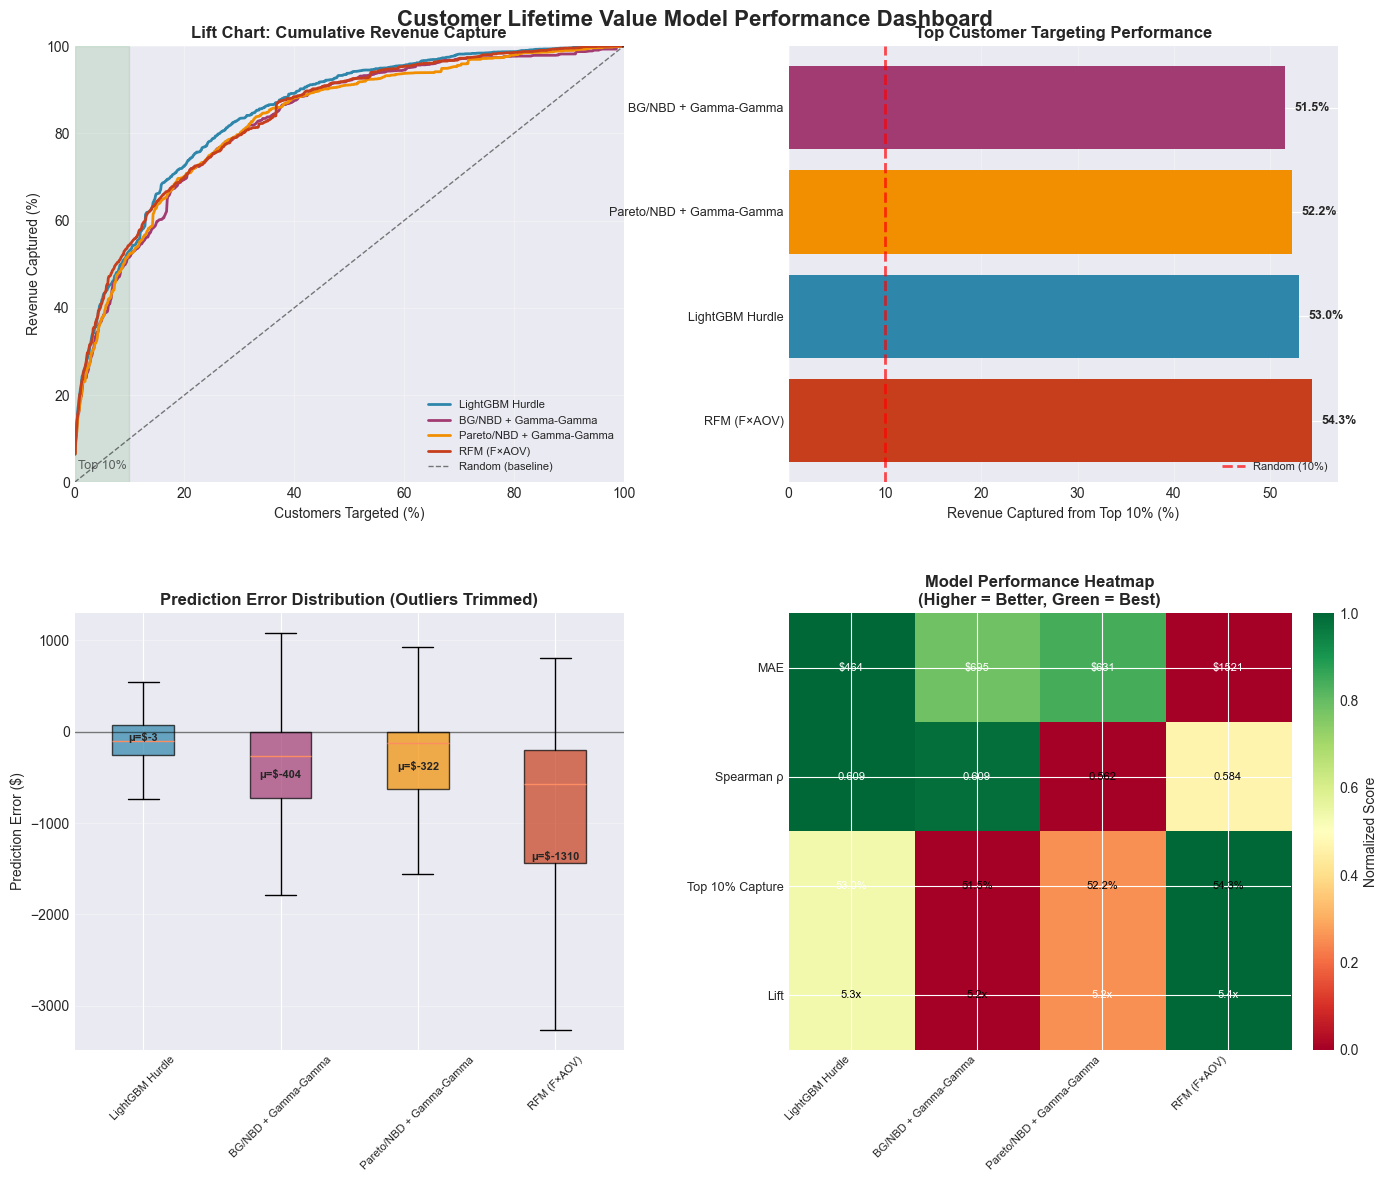


DASHBOARD INSIGHTS
Best for targeting top customers: RFM (F×AOV)
   → Captures 54.3% of revenue from top 10%

Best overall prediction accuracy: LightGBM Hurdle
   → MAE: $463.69
   → 69.5% improvement over RFM baseline

Best ranking correlation: LightGBM Hurdle
   → Spearman ρ = 0.609



In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

print("\n" + "="*60)
print("GENERATING MODEL PERFORMANCE DASHBOARD")
print("="*60)

# Prepare merged data for probabilistic models
if LIFETIMES_AVAILABLE and 'pred_revenue_bg' in test_summary.columns:
    if 'future_revenue' not in test_summary.columns:
        test_summary = test_summary.merge(
            test_data[['customer_id', 'future_revenue']], 
            on='customer_id', 
            how='left'
        )

# Create unified dataframe
plot_df = test_data[['customer_id', 'future_revenue']].copy()

# Add LightGBM predictions
if 'pred_future_revenue' in test_data.columns:
    plot_df['LightGBM Hurdle'] = test_data['pred_future_revenue']
else:
    plot_df['LightGBM Hurdle'] = np.nan

# Add RFM predictions
plot_df['RFM (F×AOV)'] = test_data['frequency'] * test_data['avg_order_value']

# Add probabilistic predictions if available
if LIFETIMES_AVAILABLE and 'pred_revenue_bg' in test_summary.columns:
    plot_df = plot_df.merge(
        test_summary[['customer_id', 'pred_revenue_bg', 'pred_revenue_pnbd']], 
        on='customer_id', 
        how='left'
    )
    plot_df['BG/NBD + Gamma-Gamma'] = plot_df['pred_revenue_bg']
    plot_df['Pareto/NBD + Gamma-Gamma'] = plot_df['pred_revenue_pnbd']
    plot_df = plot_df.drop(['pred_revenue_bg', 'pred_revenue_pnbd'], axis=1)

# Remove rows with no future revenue data
plot_df = plot_df.dropna(subset=['future_revenue'])

# Define models to plot (excluding NaN columns)
models = [col for col in ['LightGBM Hurdle', 'BG/NBD + Gamma-Gamma', 
                          'Pareto/NBD + Gamma-Gamma', 'RFM (F×AOV)'] 
          if col in plot_df.columns and plot_df[col].notna().any()]

print(f"Plotting {len(models)} models: {models}")

# Create 2x2 dashboard
fig = plt.figure(figsize=(14, 12))
fig.suptitle('Customer Lifetime Value Model Performance Dashboard', fontsize=16, fontweight='bold', y=0.98)

# Color palette for consistent model colors
model_colors = {
    'LightGBM Hurdle': '#2E86AB',
    'BG/NBD + Gamma-Gamma': '#A23B72',
    'Pareto/NBD + Gamma-Gamma': '#F18F01',
    'RFM (F×AOV)': '#C73E1D'
}

# ============================================================================
# PLOT 1: Lift Chart (Top Left)
# ============================================================================
ax1 = plt.subplot(2, 2, 1)

for model in models:
    df_temp = plot_df[['future_revenue', model]].dropna().copy()
    df_temp = df_temp.sort_values(model, ascending=False)
    df_temp['cumulative_actual'] = df_temp['future_revenue'].cumsum()
    df_temp['cumulative_percent'] = (df_temp['cumulative_actual'] / df_temp['future_revenue'].sum()) * 100
    df_temp['customer_percent'] = (np.arange(len(df_temp)) + 1) / len(df_temp) * 100
    
    ax1.plot(df_temp['customer_percent'], df_temp['cumulative_percent'], 
             linewidth=2, color=model_colors.get(model, 'gray'), label=model)

# Random baseline
ax1.plot([0, 100], [0, 100], 'k--', linewidth=1, alpha=0.5, label='Random (baseline)')

ax1.set_xlabel('Customers Targeted (%)', fontsize=10)
ax1.set_ylabel('Revenue Captured (%)', fontsize=10)
ax1.set_title('Lift Chart: Cumulative Revenue Capture', fontsize=12, fontweight='bold')
ax1.legend(loc='lower right', fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 100)
ax1.set_ylim(0, 100)
ax1.axvspan(0, 10, alpha=0.1, color='green')
ax1.text(5, 3, 'Top 10%', ha='center', fontsize=9, alpha=0.7)

# ============================================================================
# PLOT 2: Top 10% Capture Rate (Top Right)
# ============================================================================
ax2 = plt.subplot(2, 2, 2)

capture_data = []
model_labels = []

for model in models:
    df_temp = plot_df[['future_revenue', model]].dropna().copy()
    if len(df_temp) > 0:
        df_temp = df_temp.sort_values(model, ascending=False)
        total_actual = df_temp['future_revenue'].sum()
        if total_actual > 0:
            top10_count = max(1, int(len(df_temp) * 0.1))
            top10_capture = df_temp.head(top10_count)['future_revenue'].sum() / total_actual * 100
            capture_data.append(top10_capture)
            model_labels.append(model)

# Sort by capture rate
sorted_idx = np.argsort(capture_data)[::-1]
capture_data = [capture_data[i] for i in sorted_idx]
model_labels = [model_labels[i] for i in sorted_idx]

bars = ax2.barh(range(len(model_labels)), capture_data, 
                color=[model_colors.get(m, 'gray') for m in model_labels])

ax2.set_yticks(range(len(model_labels)))
ax2.set_yticklabels(model_labels, fontsize=9)
ax2.set_xlabel('Revenue Captured from Top 10% (%)', fontsize=10)
ax2.set_title('Top Customer Targeting Performance', fontsize=12, fontweight='bold')
ax2.axvline(x=10, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Random (10%)')
ax2.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (bar, value) in enumerate(zip(bars, capture_data)):
    ax2.text(value + 1, bar.get_y() + bar.get_height()/2, 
             f'{value:.1f}%', va='center', fontweight='bold', fontsize=9)

ax2.legend(loc='lower right', fontsize=8)

# ============================================================================
# PLOT 3: Error Distribution (Bottom Left)
# ============================================================================
ax3 = plt.subplot(2, 2, 3)

errors_data = []
error_labels = []

for model in models:
    df_temp = plot_df[['future_revenue', model]].dropna().copy()
    if len(df_temp) > 0:
        errors = df_temp['future_revenue'] - df_temp[model]
        # Trim outliers for better visualization (1st to 99th percentile)
        errors = errors.clip(lower=errors.quantile(0.01), upper=errors.quantile(0.99))
        errors_data.append(errors)
        error_labels.append(model)

if len(errors_data) > 0:
    bp = ax3.boxplot(errors_data, labels=error_labels, patch_artist=True, showfliers=False)
    
    # Color the boxes
    for patch, model in zip(bp['boxes'], error_labels):
        patch.set_facecolor(model_colors.get(model, 'gray'))
        patch.set_alpha(0.7)
    
    ax3.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
    ax3.set_ylabel('Prediction Error ($)', fontsize=10)
    ax3.set_title('Prediction Error Distribution (Outliers Trimmed)', fontsize=12, fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='y')
    ax3.tick_params(axis='x', rotation=45, labelsize=8)
    
    # Add mean error annotations
    for i, (errors, model) in enumerate(zip(errors_data, error_labels)):
        mean_error = errors.mean()
        ax3.text(i+1, mean_error, f'μ=${mean_error:.0f}', 
                 ha='center', va='bottom' if mean_error > 0 else 'top', 
                 fontsize=8, fontweight='bold')

# ============================================================================
# PLOT 4: Key Metrics Heatmap (Bottom Right)
# ============================================================================
ax4 = plt.subplot(2, 2, 2)
# We already used position 2, so use position 4
ax4 = plt.subplot(2, 2, 4)

# Calculate metrics for each model
metrics = []
for model in models:
    df_temp = plot_df[['future_revenue', model]].dropna().copy()
    if len(df_temp) > 0 and df_temp[model].std() > 0:
        mae = mean_absolute_error(df_temp['future_revenue'], df_temp[model])
        spearman_corr, _ = spearmanr(df_temp['future_revenue'], df_temp[model])
        
        # Calculate top 10% capture
        df_sorted = df_temp.sort_values(model, ascending=False)
        total_actual = df_temp['future_revenue'].sum()
        top10_count = max(1, int(len(df_temp) * 0.1))
        top10_capture = df_sorted.head(top10_count)['future_revenue'].sum() / total_actual * 100 if total_actual > 0 else 0
        
        metrics.append({
            'Model': model,
            'MAE': mae,
            'Spearman ρ': spearman_corr,
            'Top 10% Capture': top10_capture,
            'Lift': top10_capture / 10
        })

if len(metrics) > 0:
    metrics_df = pd.DataFrame(metrics).set_index('Model')
    
    # Normalize for heatmap (higher is better for all except MAE)
    normalized_df = metrics_df.copy()
    for col in normalized_df.columns:
        if col == 'MAE':
            normalized_df[col] = 1 - (normalized_df[col] - normalized_df[col].min()) / (normalized_df[col].max() - normalized_df[col].min())
        else:
            normalized_df[col] = (normalized_df[col] - normalized_df[col].min()) / (normalized_df[col].max() - normalized_df[col].min())
    
    # Create heatmap
    im = ax4.imshow(normalized_df.T, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    
    # Add labels
    ax4.set_xticks(range(len(normalized_df.index)))
    ax4.set_xticklabels(normalized_df.index, rotation=45, ha='right', fontsize=8)
    ax4.set_yticks(range(len(normalized_df.columns)))
    ax4.set_yticklabels(normalized_df.columns, fontsize=9)
    
    # Add value annotations
    for i in range(len(normalized_df.columns)):
        for j in range(len(normalized_df.index)):
            value = metrics_df.iloc[j, i]
            if normalized_df.columns[i] == 'MAE':
                text = f'${value:.0f}'
            elif normalized_df.columns[i] == 'Spearman ρ':
                text = f'{value:.3f}'
            elif normalized_df.columns[i] == 'Lift':
                text = f'{value:.1f}x'
            else:
                text = f'{value:.1f}%'
            
            ax4.text(j, i, text, ha='center', va='center', fontsize=8, 
                    color='white' if normalized_df.iloc[i, j] > 0.5 else 'black')
    
    ax4.set_title('Model Performance Heatmap\n(Higher = Better, Green = Best)', fontsize=12, fontweight='bold')
    
    # Add colorbar
    plt.colorbar(im, ax=ax4, fraction=0.046, pad=0.04, label='Normalized Score')

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(top=0.95, hspace=0.3, wspace=0.3)
plt.show()

# ============================================================================
# Print Summary Statistics Below Dashboard
# ============================================================================
print("\n" + "="*60)
print("DASHBOARD INSIGHTS")
print("="*60)

# Best for targeting
best_capture_idx = np.argmax(capture_data) if len(capture_data) > 0 else None
if best_capture_idx is not None:
    print(f"Best for targeting top customers: {model_labels[best_capture_idx]}")
    print(f"   → Captures {capture_data[best_capture_idx]:.1f}% of revenue from top 10%")

# Best MAE
if len(metrics) > 0:
    metrics_df_sorted = metrics_df.sort_values('MAE')
    best_model = metrics_df_sorted.index[0]
    best_mae = metrics_df_sorted.iloc[0]['MAE']
    print(f"\nBest overall prediction accuracy: {best_model}")
    print(f"   → MAE: ${best_mae:.2f}")
    
    # Improvement over RFM
    if 'RFM (F×AOV)' in metrics_df.index:
        rfm_mae = metrics_df.loc['RFM (F×AOV)', 'MAE']
        improvement = ((rfm_mae - best_mae) / rfm_mae) * 100
        print(f"   → {improvement:.1f}% improvement over RFM baseline")

# Spearman correlation leader
if len(metrics) > 0:
    best_spearman = metrics_df.loc[metrics_df['Spearman ρ'].idxmax(), 'Spearman ρ']
    best_spearman_model = metrics_df['Spearman ρ'].idxmax()
    print(f"\nBest ranking correlation: {best_spearman_model}")
    print(f"   → Spearman ρ = {best_spearman:.3f}")

print("\n" + "="*60)

In [17]:
import os
import json
import pandas as pd
import numpy as np

SAVE_DIR = "saved_analysis_states"
os.makedirs(SAVE_DIR, exist_ok=True)
saved_items = []
failed_items = []

# Save state_table
try:
    state_table.to_parquet(f"{SAVE_DIR}/state_table.parquet")
    saved_items.append(f"state_table ({len(state_table)} rows)")
except NameError:
    failed_items.append("state_table (not found in notebook)")



# Save customer splits
splits = {}
for name in ['train_customers', 'val_customers', 'test_customers']:
    if name in globals():
        customers = globals()[name]
        splits[name] = customers.tolist() if hasattr(customers, 'tolist') else list(customers)

if splits:
    with open(f"{SAVE_DIR}/data_splits.json", 'w') as f:
        json.dump(splits, f)
    saved_items.append(f"data_splits ({len(splits)} sets)")
else:
    failed_items.append("data_splits (no split variables found)")

# Save metadata
try:
    metadata = {
        "saved_at": pd.Timestamp.now().isoformat(),
        "snapshot_date": str(snapshot_date.date()),
        "holdout_days": int(holdout_days),
        "items_saved": saved_items
    }
    with open(f"{SAVE_DIR}/metadata.json", 'w') as f:
        json.dump(metadata, f, indent=2)
    saved_items.append("metadata.json")
except Exception as e:
    failed_items.append(f"metadata (error: {e})")

# Summary
print(f"\nSaved to '{SAVE_DIR}/':")
for item in saved_items:
    print(f"  • {item}")

if failed_items:
    print(f"\nSkipped:")
    for item in failed_items:
        print(f"  • {item}")

# Verify files on disk
print(f"\nFiles on disk:")
for f in os.listdir(SAVE_DIR):
    size_mb = os.path.getsize(f"{SAVE_DIR}/{f}") / 1024 / 1024
    print(f"  • {f}: {size_mb:.2f} MB")


Saved to 'saved_analysis_states/':
  • state_table (4716 rows)
  • test_data (944 rows)
  • test_summary (944 rows)
  • data_splits (3 sets)
  • metadata.json

Files on disk:
  • data_splits.json: 0.05 MB
  • metadata.json: 0.00 MB
  • state_table.parquet: 0.38 MB
  • test_data.parquet: 0.14 MB
  • test_summary.parquet: 0.06 MB


In [18]:

os.makedirs(SAVE_DIR, exist_ok=True)

# ── Build mart ────────────────────────────────────────────────
mart_2 = test_data[['customer_id', 'future_revenue']].copy()

# Metadata for context
mart_2['split'] = 'test'
mart_2['snapshot_date'] = snapshot_date.date()
mart_2['holdout_days'] = holdout_days

# LightGBM predictions and components
mart_2['pred_lightgbm']  = test_data['pred_future_revenue']
mart_2['p_active']       = test_data['p_active']
mart_2['pred_frequency'] = test_data['pred_frequency_conditional']
mart_2['pred_aov']       = test_data['pred_monetary_conditional']

# RFM baseline
mart_2['pred_rfm'] = test_data['frequency'] * test_data['avg_order_value']

# Probabilistic models
try:
    prob_preds = test_summary[['customer_id', 'pred_revenue_bg', 'pred_revenue_pnbd']].copy()
    prob_preds = prob_preds.rename(columns={
        'pred_revenue_bg':   'pred_bgnbd',
        'pred_revenue_pnbd': 'pred_pareto'
    })
    mart_2 = mart_2.merge(prob_preds, on='customer_id', how='left')
    
    for col in ['pred_bgnbd', 'pred_pareto']:
        n_missing = mart_2[col].isna().sum()
        if n_missing > 0:
            print(f"  {n_missing} customers missing {col}")
except NameError:
    print("  test_summary not found")
    mart_2['pred_bgnbd'] = np.nan
    mart_2['pred_pareto'] = np.nan

# ── Pre-compute errors for segmentation analysis ─────────────
models = ['lightgbm', 'rfm', 'bgnbd', 'pareto']

for model in models:
    pred_col = f'pred_{model}'
    if pred_col in mart_2.columns:
        # Error (actual - predicted)
        mart_2[f'error_{model}'] = mart_2['future_revenue'] - mart_2[pred_col]
        
        # Absolute error (for MAE)
        mart_2[f'ae_{model}'] = mart_2[f'error_{model}'].abs()
        
        # Squared error (for RMSE)
        mart_2[f'se_{model}'] = mart_2[f'error_{model}'] ** 2
        
        # Rank for top N% analysis
        mart_2[f'rank_{model}'] = mart_2[pred_col].rank(ascending=False, method='dense')

# ── Validate no duplicate customers ──────────────────────────
n_dupes = mart_2['customer_id'].duplicated().sum()
if n_dupes > 0:
    print(f"  {n_dupes} duplicate customers")
else:
    print(f" No duplicate customers")

# ── Save ─────────────────────────────────────────────────────
save_path = f"{SAVE_DIR}/model_evaluation_mart.parquet"
mart_2.to_parquet(save_path, index=False)

# ── Summary ──────────────────────────────────────────────────
size_kb = os.path.getsize(save_path) / 1024
print(f"\n Mart saved: {len(mart_2)} test customers")
print(f"   Path: {save_path}")
print(f"   Size: {size_kb:.1f} KB")
print(f"   Columns: {list(mart_2.columns)}")

print(f"\n Prediction coverage:")
for col in ['pred_lightgbm', 'pred_rfm', 'pred_bgnbd', 'pred_pareto']:
    if col in mart_2.columns:
        pct = mart_2[col].notna().mean() * 100
        print(f"   • {col}: {pct:.1f}%")

print(f"\n Pre-computed metrics available:")
metric_cols = [c for c in mart_2.columns if any(x in c for x in ['error_', 'ae_', 'se_', 'rank_'])]
for col in metric_cols[:8]:
    print(f"   • {col}")

print(f"\nFirst 3 rows:")
print(mart_2.head(3))

  150 customers missing pred_bgnbd
 No duplicate customers

 Mart saved: 944 test customers
   Path: saved_analysis_states/model_evaluation_mart.parquet
   Size: 175.5 KB
   Columns: ['customer_id', 'future_revenue', 'split', 'snapshot_date', 'holdout_days', 'pred_lightgbm', 'p_active', 'pred_frequency', 'pred_aov', 'pred_rfm', 'pred_bgnbd', 'pred_pareto', 'error_lightgbm', 'ae_lightgbm', 'se_lightgbm', 'rank_lightgbm', 'error_rfm', 'ae_rfm', 'se_rfm', 'rank_rfm', 'error_bgnbd', 'ae_bgnbd', 'se_bgnbd', 'rank_bgnbd', 'error_pareto', 'ae_pareto', 'se_pareto', 'rank_pareto']

 Prediction coverage:
   • pred_lightgbm: 100.0%
   • pred_rfm: 100.0%
   • pred_bgnbd: 84.1%
   • pred_pareto: 100.0%

 Pre-computed metrics available:
   • error_lightgbm
   • ae_lightgbm
   • se_lightgbm
   • rank_lightgbm
   • error_rfm
   • ae_rfm
   • se_rfm
   • rank_rfm

First 3 rows:
  customer_id  future_revenue split snapshot_date  holdout_days  \
0     12349.0             0.0  test    2011-04-01          